In [30]:
# data sets
# from torch_geometric.datasets import QM9 # we will not be using QM9
from tdc.utils import get_reaction_type

# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage

# standard libraries
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model. Structure it to use in model.

In [31]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}
molecule_types_df = pd.read_csv("Collected Data/Alchemy-v20191129/final_version_with_smiles.csv")
reaction_types_df = pd.read_csv("Collected Data/uspto_50k_processed.csv")

display(molecule_types_df)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom update its features by aggreating from its neighbors. After this messaging, pool atoms to molecule to predict the target features that will be used in the decision tree for the reaction type. Now, for the decision tree that takes in these 12 output target features, I don't want redundancy. So I will remove the ones that have overlap.

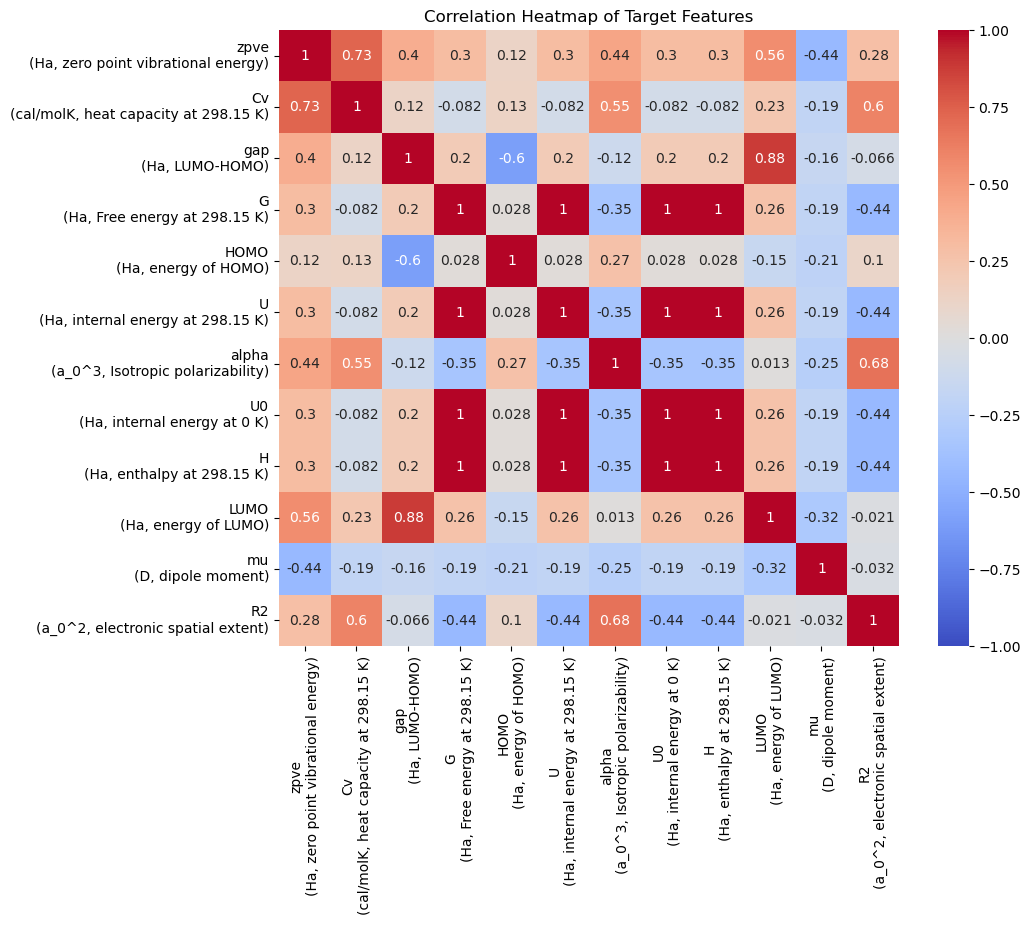

In [32]:
# just the target features for the molecules, which we will be trying to predict with our GNN and use as input into decision tree
# 12/15 are valid physics values for this model (smiles is already the graph, gdb_idx was just to help find smiles, atom number has no physics)
molecule_targets_df = molecule_types_df.drop(columns=['smiles', 'gdb_idx', 'atom number'])

# correlation heatmap of the target features
plt.figure(figsize=(10, 8))
sns.heatmap(molecule_targets_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Target Features")
plt.show()

Of the 12, some of the thermodynamic ones seem redundant, so let's cut those and not waste time in the GNN calculating them cause they're not going in the decision tree. There will be nine remaining.

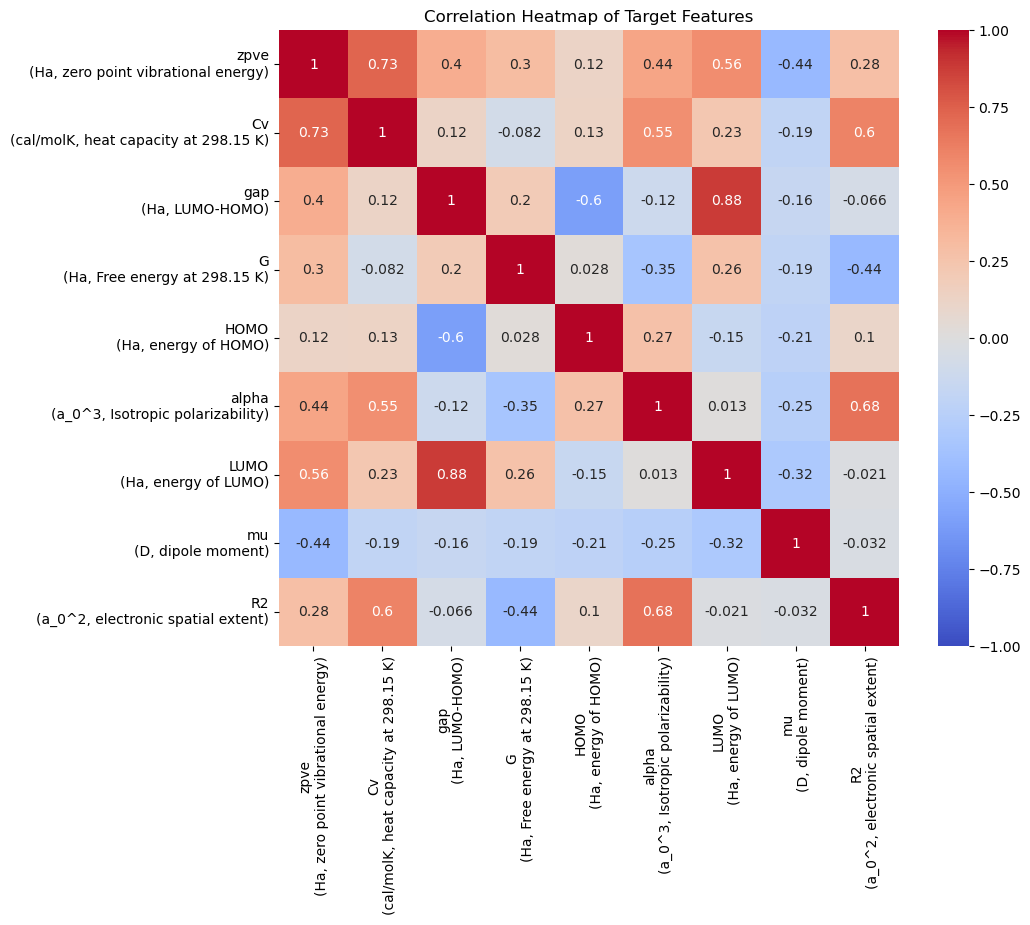

In [33]:
# G, U, U0, H 
# Thermo: G = U + PV - TS = H - TS, so we only really need one of these. 
# Let's keep G because all the chemists love G
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'U\n(Ha, internal energy at 298.15 K)',
    'U0\n(Ha, internal energy at 0 K)', 
    'H\n(Ha, enthalpy at 298.15 K)', 
])

# correlation heatmap of the target features
plt.figure(figsize=(10, 8))
sns.heatmap(molecule_targets_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Target Features")
plt.show()

### (2) Focus on making the GNN with the alchemy DFT data. Use only a fraction of the data so I can practically run this.

In [34]:
# Create a smaller dataframe with a random sample of molecules from the alchemy dataset to work with locally. 

n_examples = 5000
small_molecule_types_df = molecule_types_df.sample(n=n_examples, random_state=67).reset_index(drop=True)
display(small_molecule_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles
0,82642,11,0.239593,0.000072,0.250232,-502.508749,-0.229935,-502.459791,102.959327,-502.471522,-502.458847,0.020297,1.512989,1967.048763,C[C@H]1CC=C([C@@H](C)O)COC1
1,6264428,10,0.211166,0.000063,0.253778,-463.251265,-0.233838,-463.205069,91.842329,-463.215543,-463.204124,0.019940,1.596246,1668.965710,C[C@@H]1CCC=C[C@H](CO)O1
2,8761235,10,0.188067,0.000058,0.210123,-462.067952,-0.224407,-462.022419,87.223858,-462.032162,-462.021475,-0.014284,3.297574,1615.944140,CCO[C@H]1C[C@@H]2C[C@@H]2C1=O
3,6640342,10,0.181395,0.000065,0.305293,-859.209539,-0.249505,-859.160915,88.868316,-859.172083,-859.159971,0.055788,3.884206,1885.743617,C[C@H]1OC[C@H]1CS(C)(=O)=O
4,153469,11,0.183893,0.000060,0.183995,-479.110377,-0.202056,-479.065248,101.050507,-479.075051,-479.064304,-0.018062,5.452225,1645.648609,CC1=CC(=O)[C@H]2CC=C[C@H]2N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5769183,12,0.174097,0.000068,0.182649,-570.272903,-0.254590,-570.223899,97.618070,-570.235352,-570.222955,-0.071940,5.825090,1847.503090,N#CC(=O)[C@@H]1NC[C@@H]1C1(O)CC1
4996,6487574,11,0.224063,0.000079,0.126059,-535.119847,-0.177712,-535.065836,101.128011,-535.079351,-535.064892,-0.051653,2.835261,2169.893190,C[C@@H]1C[C@H](N)C2([NH2+]1)[C@H](O)[C@H]2O
4997,2381774,10,0.126333,0.000055,0.203667,-761.533169,-0.231780,-761.489428,100.535319,-761.498389,-761.488483,-0.028113,1.452428,1680.661511,C#CC1(c2ccsn2)CC1
4998,6572789,9,0.199144,0.000070,0.133468,-441.800727,-0.184258,-441.747563,82.177022,-441.760434,-441.746619,-0.050791,0.267437,1597.845057,C[C@H]1OC[C@@H](O)[C@@]1(C)[NH3+]


In [35]:
def smiles_to_graph(smi, y): 
    """
    Convert a SMILES string to a PyTorch Geometric Data object representing the molecular graph.
    Nodes represent atoms, and edges represent bonds. 
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    
    # atom features
    atom_features = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float).unsqueeze(1)
    
    # edges
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))
        # undirected graph, both directions
    
    # convert to tensor
    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    # targets
    y = torch.tensor(y, dtype=torch.float).unsqueeze(0)

    return Data(x=x, edge_index=edge_index, y=y) # already is a class that can be used with DataLoader

In [36]:
# turn all the data into a graph for use in the GNN
# molecule_targets_df is the target columns

graph_dataset = []
for idx, row in small_molecule_types_df.iterrows():
    graph = smiles_to_graph(
        row['smiles'], 
        row[molecule_targets_df.columns].astype(float).values
    )
    if graph is not None:
        graph_dataset.append(graph)

g = graph_dataset[0]
print(g.x.shape)            # [num_atoms, 1]
print(g.edge_index.shape)   # [2, num_edges]
print(g.y.shape)            # should be 9
# okay great nothing exploded

torch.Size([11, 1])
torch.Size([2, 22])
torch.Size([1, 9])


In [37]:
# normalize the targets

all_y = torch.stack([g.y for g in graph_dataset])
y_mean = all_y.mean(dim = 0)
y_std = all_y.std(dim = 0).clamp_min(1e-8) # avoid div by 0 error

for g in graph_dataset: 
    g.y = (g.y - y_mean) / y_std

In [38]:
class GNN(torch.nn.Module): 
    # screw around with the hidden_dim to get better regression statistic
    # number of y predictions is out_dim in case of future change
    def __init__(self, in_channels=1, hidden_dim=128, out_dim = molecule_targets_df.shape[1], dropout=0.2): 
        super().__init__()

        # A larger graph model with three graph convolution layers
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch): 
        # first graph convolution block
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # second graph convolution block
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # third graph convolution block
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # pool from atom space to molecule space
        x = global_mean_pool(x, batch)

        # readout MLP
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.lin2(x)
        return x
        
class Trainer: 
    def __init__(self, model, lr = 1e-3, device = "cpu"): 
        self.model = model.to(device)
        self.device = device 
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr = lr)
        self.loss_function = torch.nn.MSELoss()

    def train_one_epoch(self, loader): 
        self.model.train() # training 'mode' as per tutorial 
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device)

            self.optimizer.zero_grad() # grad not needed as we evaluate
            pred = self.model(batch.x, batch.edge_index, batch.batch)
            loss = self.loss_function(pred, batch.y)
            loss.backward() # find the gradients
            self.optimizer.step() # update the weights

            total_loss += loss.item()
        
        return total_loss / len(loader) # average loss per batch 
    
    # used for testing phase
    @torch.no_grad()
    def evaluate(self, loader): 
        self.model.eval()
        total_loss = 0.0
        all_preds = []  # Collect all predictions
        all_targets = []  # Collect all targets

        for batch in loader: 
            batch = batch.to(self.device) 
            pred = self.model(batch.x, batch.edge_index, batch.batch) 
            loss = self.loss_function(pred, batch.y)
            total_loss += loss.item()
            all_preds.append(pred.cpu())  # Store predictions for R² calculation
            all_targets.append(batch.y.cpu())  # Store targets for R² calculation
        
        all_preds = torch.cat(all_preds, dim=0)  # Concatenate all predictions
        all_targets = torch.cat(all_targets, dim=0)  # Concatenate all targets
        
        # Compute average R² across outputs (measure of accuracy for regression)
        ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)  # Sum of squared residuals per output
        ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0)  # Total sum of squares per output
        r2_per_output = 1 - (ss_res / ss_tot)  # R² per output
        avg_r2 = r2_per_output.mean().item()  # Average R² across all outputs
        
        return total_loss / len(loader), avg_r2
    
    def fit(self, train_loader, val_loader, epochs = 20, show_progress = True): 
        train_losses = []
        val_losses = []
        val_r2s = []  # Track R² history

        best_val = float("inf")
        best_train = None
        best_val_r2 = -float("inf")  # Track best R²

        for epoch in range(1, epochs +1): 
            train_loss = self.train_one_epoch(train_loader)
            val_loss, val_r2 = self.evaluate(val_loader)  # Now returns loss and R²

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_r2s.append(val_r2)  # Append R² for this epoch

            if val_loss < best_val: 
                best_val = val_loss
                best_train = train_loss
                best_val_r2 = val_r2  # Update best R²

            if show_progress: 
                print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}, r2={val_r2:.4f}")  # Include R² in progress

        return {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_r2s": val_r2s,  # Include R² history
            "best_train_loss": best_train,
            "best_val_loss": best_val,
            "best_val_r2": best_val_r2  # Include best R²
        }


In [39]:
# this is the stucture from homework 7, I am going to appropriate for my needs
# replace accuracy with the R^2 regression statistic

def KFoldCrossValidation(
        model_class,
        graph_dataset,
        k = 3, 
        batch_size = 32, 
        epochs = 20, 
        device = "cpu", 
        early_break = False
): 
    
    kf = KFold(n_splits = k, shuffle = True, random_state=67)

    train_loss_list = []
    val_loss_list = []
    val_r2_list = []  # List to store best validation R² for each fold
    all_train_losses = []  # List to store full training loss history for each fold
    all_val_losses = []  # List to store full validation loss history for each fold
    all_val_r2s = []  # List to store full validation R² history for each fold

    for fold, (train_idx, val_idx) in enumerate(kf.split(graph_dataset)): 
        print(f"\nFold {fold+1}")

        # split data 
        train_graphs = [graph_dataset[i] for i in train_idx]
        val_graphs = [graph_dataset[i] for i in val_idx]

        # loaders 
        train_loader = DataLoader(train_graphs, batch_size = batch_size, shuffle = True)
        val_loader = DataLoader(val_graphs, batch_size = batch_size, shuffle = False)

        # new model class each fold
        model = model_class()
        trainer = Trainer(model, device = device)

        # train 
        results = trainer.fit(train_loader, val_loader, epochs = epochs, show_progress = False)

        train_loss_best = results["best_train_loss"]
        val_loss_best  = results["best_val_loss"]
        val_r2_best = results["best_val_r2"]  # Best validation R² from this fold

        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        val_r2_list.append(val_r2_best)  # Append best R² for final averaging
        all_train_losses.append(results["train_losses"])  # Append full train loss history
        all_val_losses.append(results["val_losses"])  # Append full val loss history
        all_val_r2s.append(results["val_r2s"])  # Append full val R² history

        print(f"Best train loss: {train_loss_best:.4f}")
        print(f"Best val loss: {val_loss_best:.4f}")
        print(f"Best val R²: {val_r2_best:.4f}")  # Print R² for this fold

        if early_break:
            break

    # Compute average losses and R² per epoch across folds
    avg_train_losses = np.mean(np.array(all_train_losses), axis=0)  # Average train loss per epoch
    avg_val_losses = np.mean(np.array(all_val_losses), axis=0)  # Average val loss per epoch
    avg_val_r2s = np.mean(np.array(all_val_r2s), axis=0)  # Average val R² per epoch

    # Plot the loss curves to show decreasing loss
    plt.figure(figsize=(10, 6))
    plt.plot(avg_train_losses, label='Average Train Loss')
    plt.plot(avg_val_losses, label='Average Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Validation Loss Curves (K-Fold Cross-Validation)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot the R² curve as a measure of accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(avg_val_r2s, label='Average Validation R²', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('R²')
    plt.title('Validation R² Curve (K-Fold Cross-Validation)')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\nFinal results:")
    print(f"Train loss: {np.mean(train_loss_list):.4f} ± {np.std(train_loss_list):.4f}")
    print(f"Val loss: {np.mean(val_loss_list):.4f} ± {np.std(val_loss_list):.4f}")
    print(f"Val R²: {np.mean(val_r2_list):.4f} ± {np.std(val_r2_list):.4f}")  # Average R² across folds as accuracy measure



Fold 1
Best train loss: 0.6430
Best val loss: 0.6332
Best val R²: 0.3682

Fold 2
Best train loss: 0.6430
Best val loss: 0.6466
Best val R²: 0.3715

Fold 3
Best train loss: 0.6480
Best val loss: 0.6121
Best val R²: 0.3769


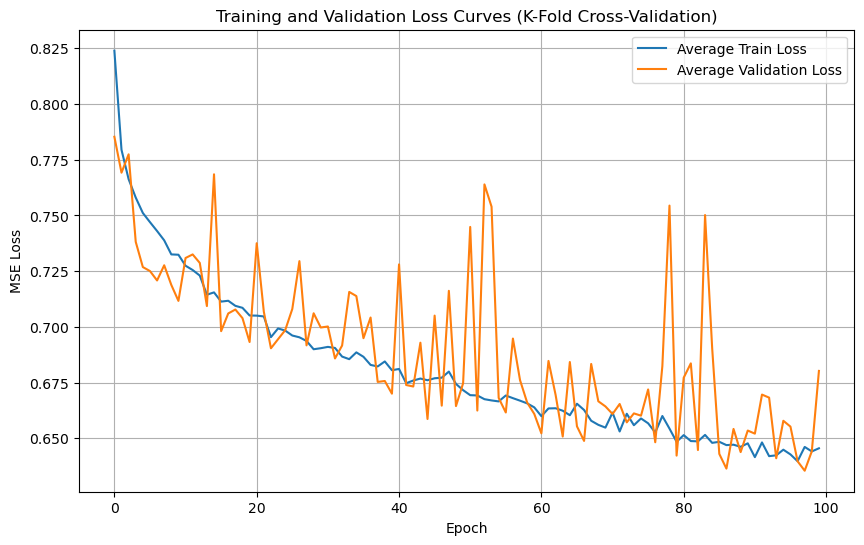

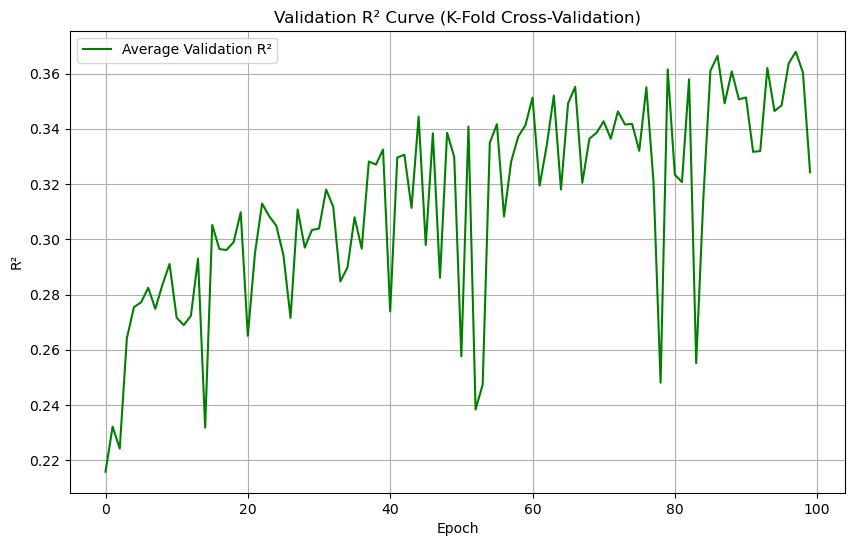


Final results:
Train loss: 0.6447 ± 0.0023
Val loss: 0.6306 ± 0.0142
Val R²: 0.3722 ± 0.0036


In [40]:
# the pain and suffering of a mac user
device = "mps" if torch.cuda.is_available() else "cpu"

KFoldCrossValidation(
    model_class=GNN,
    graph_dataset=graph_dataset,
    k=3,
    batch_size=32,
    epochs=100,
    device=device
)
# 4 minutes 22 sec with n_examples = 5

### (2.1) Side code, not as relevent: PCA on target features and K-fold comparison
Run PCA on the 9 target features, build a new graph dataset with the reduced PCA targets, and compare the K-fold results to the original model.
Result: Does not really help with the noise, but deal with that later in Checkpoint #3.

Explained variance ratio (cumulative): [0.91708518 0.99956355 0.99998663 0.99999996 0.99999999 1.
 1.         1.         1.        ]
Total explained variance by first 9 components: 0.9999999999999999
PCA graph dataset size: 5000

Fold 1
Best train loss: 0.6529
Best val loss: 0.6154
Best val R²: 0.3766

Fold 2
Best train loss: 0.6348
Best val loss: 0.6372
Best val R²: 0.3746

Fold 3
Best train loss: 0.6508
Best val loss: 0.6156
Best val R²: 0.3837


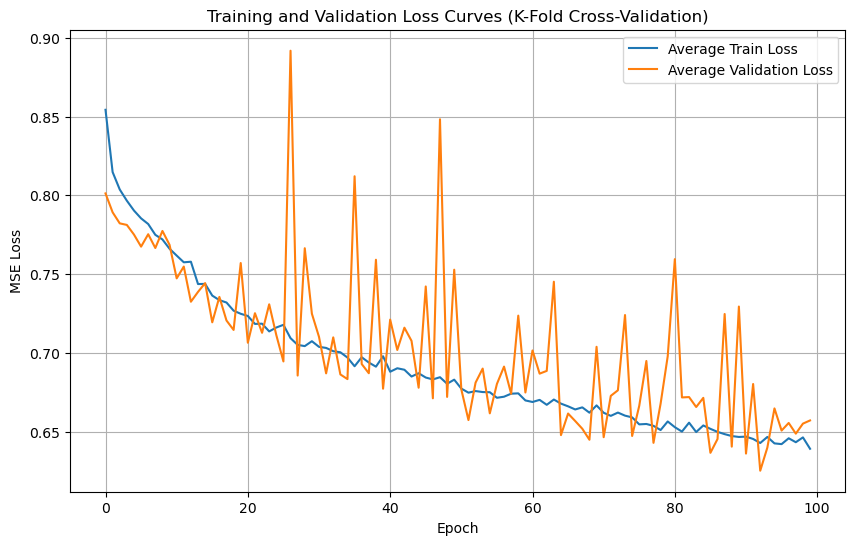

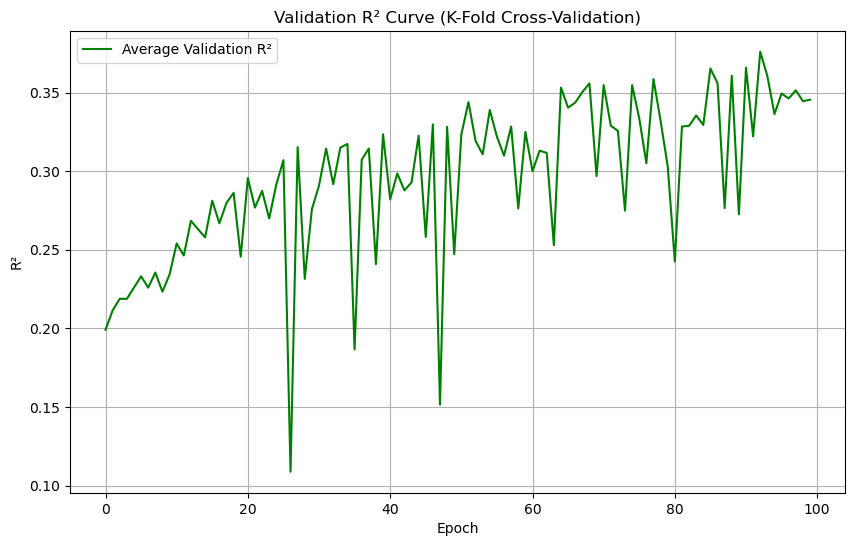


Final results:
Train loss: 0.6462 ± 0.0081
Val loss: 0.6227 ± 0.0102
Val R²: 0.3783 ± 0.0039


In [41]:
from sklearn.decomposition import PCA

# Select PCA components to keep most of the target variance
n_pca_components = 9

# Original target matrix from the sampled molecules
target_matrix = small_molecule_types_df[molecule_targets_df.columns].astype(float).values

pca = PCA(n_components=n_pca_components, random_state=67)
target_pca = pca.fit_transform(target_matrix)

print("Explained variance ratio (cumulative):", np.cumsum(pca.explained_variance_ratio_))
print("Total explained variance by first", n_pca_components, "components:", np.sum(pca.explained_variance_ratio_))

# Normalize PCA targets before using them for training
pca_mean = target_pca.mean(axis=0)
pca_std = target_pca.std(axis=0).clip(min=1e-8)
target_pca_norm = (target_pca - pca_mean) / pca_std

# Build a new graph dataset with PCA targets
graph_dataset_pca = []
for idx, row in small_molecule_types_df.iterrows():
    graph = smiles_to_graph(row['smiles'], target_pca_norm[idx])
    if graph is not None:
        graph_dataset_pca.append(graph)

print("PCA graph dataset size:", len(graph_dataset_pca))

# Run K-fold cross-validation on the PCA target dataset
KFoldCrossValidation(
    model_class=lambda: GNN(in_channels=1, hidden_dim=128, out_dim=n_pca_components, dropout=0.2),
    graph_dataset=graph_dataset_pca,
    k=3,
    batch_size=32,
    epochs=100,
    device=device
) # 3 minutes 53 secs with PCA

### (3) Decision tree classification from GNN features
Use the trained GNN to predict molecular properties for the reactant and product SMILES, then train a simple decision tree to classify the reaction category.
This will not likely be part of the final code, but it does give me insight whether this GNN data is helpful at all whatsoever.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold

def smiles_to_graph_no_target(smi, out_dim=9):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([atom.GetAtomicNum()])
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))

    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    y = torch.zeros(out_dim, dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

def predict_gnn_features(model, smi):
    graph = smiles_to_graph_no_target(smi, out_dim=9)
    if graph is None:
        return None
    graph = graph.to(device)
    batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=device)
    model.eval()
    with torch.no_grad():
        return model(graph.x, graph.edge_index, batch).cpu().numpy()

# make a model and try out using features of GNN
feature_model = GNN(in_channels=1, hidden_dim=128, out_dim=9, dropout=0.2).to(device)
feature_trainer = Trainer(feature_model, lr=1e-3, device=device)

feature_loader = DataLoader(graph_dataset, batch_size=32, shuffle=True)
feature_trainer.fit(feature_loader, feature_loader, epochs=50, show_progress=False)

# predict the features of the molecules in the reaction scheme
reaction_features = []
reaction_labels = []

for _, row in reaction_types_df.iterrows():
    reactant_feat = predict_gnn_features(feature_model, row['reactant'])
    product_feat = predict_gnn_features(feature_model, row['product'])
    if reactant_feat is None or product_feat is None:
        continue
    reaction_features.append(np.concatenate([reactant_feat, product_feat], axis=-1))
    reaction_labels.append(row['category'])

reaction_features = np.vstack(reaction_features)
reaction_labels = np.array(reaction_labels, dtype=int)

print('Reaction examples:', reaction_features.shape)
print('Reaction categories:', np.unique(reaction_labels))

# get the classification report for the tree
clf = DecisionTreeClassifier(max_depth=6, random_state=67)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)

accuracies = []
for fold, (train_idx, test_idx) in enumerate(skf.split(reaction_features, reaction_labels), 1):
    clf.fit(reaction_features[train_idx], reaction_labels[train_idx])
    preds = clf.predict(reaction_features[test_idx])
    acc = accuracy_score(reaction_labels[test_idx], preds)
    accuracies.append(acc)
    print(f'Fold {fold} accuracy: {acc:.4f}')
    print(classification_report(reaction_labels[test_idx], preds, zero_division=0))

print(f'Average decision tree accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}')
# run time for n_examples = 5000 is 2m 30s 

Reaction examples: (35116, 18)
Reaction categories: [ 1  2  3  4  5  6  7  8  9 10]
Fold 1 accuracy: 0.4669
              precision    recall  f1-score   support

           1       0.52      0.44      0.48      2879
           2       0.43      0.65      0.51      3577
           3       0.22      0.01      0.01       290
           4       0.00      0.00      0.00       202
           5       0.95      0.11      0.19       178
           6       0.52      0.60      0.56      2518
           7       0.39      0.25      0.31      1398
           8       0.00      0.00      0.00       244
           9       0.00      0.00      0.00       411
          10       0.00      0.00      0.00         9

    accuracy                           0.47     11706
   macro avg       0.30      0.21      0.21     11706
weighted avg       0.44      0.47      0.43     11706

Fold 2 accuracy: 0.4812
              precision    recall  f1-score   support

           1       0.56      0.41      0.47      2878


50% is not bad, considering we used here like 2.5% of the molecule data. 

### (3.1) Other Idea: Use a Transformer instead of a decision tree, with and without the information gained by the GNN.